# VADER Sentiment Analysis of AI-Generated Travelogues

This notebook investigates whether AI-generated travelogues faithfully preserve the affective tone of the human-authored reference text, using VADER compound sentiment scores computed during the evaluation pipeline.

## Psychogeographic framing

Psychogeography (Debord, 1955) holds that the emotional character of a place is inseparable from the act of narrating it. A generated travelogue that systematically shifts sentiment away from the human-authored source distorts that character — either romanticising the walk (Δ > 0) or dampening its affect (Δ < 0). A Δ near 0 indicates faithful affective reproduction.

**Null hypotheses tested in Section 4:**

| ID | Hypothesis |
|----|------------|
| H₀₁ | The mean sentiment delta (Δ = AI − human) equals zero — AI and human sentiment are in alignment |
| H₀₂ | Prompting strategy (zero-shot vs. few-shot vs. meta-prompt) has no effect on Δ |
| H₀₃ | LLM model identity has no effect on Δ |

---

**VADER reference:** Hutto, C.J. & Gilbert, E.E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text. *ICWSM-14*.

**Psychogeography reference:** Debord, G. (1955). Introduction to a Critique of Urban Geography. *Les Lèvres Nues*, 6.

In [10]:
# Section 1 — Data Loading from Neo4j

import os
import sys
import pandas as pd
import numpy as np
from neo4j import GraphDatabase
from dotenv import load_dotenv

# Load environment variables (NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD)
load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), '.env'))
load_dotenv()  # fallback: current directory .env

NEO4J_URI      = os.getenv('NEO4J_URI',      'bolt://localhost:7687')
NEO4J_USER     = os.getenv('NEO4J_USER',     'neo4j')
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD', 'pXo5nUiKsadFJmW1LVBNTKUGyeAoAp2VzfFMWysGimc')

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

QUERY = """
MATCH (r:Route)-[:HAS_TRAVELOGUE]->(t:Travelogue)-[:HAS_EVALUATION]->(e:Evaluation)
WHERE t.is_valid = true
  AND e.human_sentiment IS NOT NULL
  AND e.ai_sentiment    IS NOT NULL
RETURN
    r.id              AS walk_id,
    t.llm_model       AS model_name,
    t.prompt_type     AS prompt_strategy,
    t.meta_prompted   AS meta_prompted,
    e.human_sentiment AS notes_compound,
    e.ai_sentiment    AS generated_compound,
    (e.ai_sentiment - e.human_sentiment) AS delta
ORDER BY walk_id, model_name, prompt_strategy
"""

with driver.session() as session:
    records = session.run(QUERY).data()

df = pd.DataFrame(records)

# Normalise column types
df['notes_compound']     = df['notes_compound'].astype(float)
df['generated_compound'] = df['generated_compound'].astype(float)
df['delta']              = df['delta'].astype(float)

print(f"Loaded {len(df)} evaluation records")
print(f"Walks:    {df['walk_id'].nunique()}")
print(f"Models:   {df['model_name'].unique()}")
print(f"Strategies: {df['prompt_strategy'].unique()}")
df.head()

Loaded 34 evaluation records
Walks:    4
Models:   <StringArray>
['gemma3:27b', 'llama3.1:8b', 'glm-4.6:cloud', 'gpt-oss:20b']
Length: 4, dtype: str
Strategies: <StringArray>
['few_shot', nan, 'zero_shot']
Length: 3, dtype: str


,walk_id,model_name,prompt_strategy,meta_prompted,notes_compound,generated_compound,delta
0,route-avon-ri-loop,gemma3:27b,few_shot,None,0.8911,0.9899,0.0988
1,route-avon-ri-loop,llama3.1:8b,NaN,None,0.8911,0.9712,0.0801
2,route-cruagh-woods,gemma3:27b,few_shot,None,0.9216,-0.8189,-1.7405
3,route-cruagh-woods,gemma3:27b,few_shot,None,0.9216,0.3197,-0.6019
4,route-cruagh-woods,gemma3:27b,few_shot,None,0.9216,0.0516,-0.8700


In [11]:
# Section 2 — Descriptive Statistics

# Overall summary
print("=== Overall Sentiment Summary ===")
overall = df[['notes_compound', 'generated_compound', 'delta']].describe().T
overall.columns = overall.columns.str.capitalize()
print(overall.to_string())

print("\n=== % of evaluations preserving sentiment sign (|Δ| → same polarity) ===")
# Sign preserved = human and AI compound are the same polarity (both ≥ 0, or both < 0)
df['sign_preserved'] = ((df['notes_compound'] >= 0) == (df['generated_compound'] >= 0))
print(f"Overall: {df['sign_preserved'].mean()*100:.1f}%")

print("\n=== Descriptive Statistics by Model ===")
by_model = (
    df.groupby('model_name')['delta']
    .agg(['mean', 'median', 'std', 'count'])
    .rename(columns={'mean': 'Mean Δ', 'median': 'Median Δ', 'std': 'SD Δ', 'count': 'N'})
)
by_model['Sign Preserved %'] = (
    df.groupby('model_name')['sign_preserved'].mean() * 100
).round(1)
print(by_model.to_string())

print("\n=== Descriptive Statistics by Prompt Strategy ===")
by_strategy = (
    df.groupby('prompt_strategy')['delta']
    .agg(['mean', 'median', 'std', 'count'])
    .rename(columns={'mean': 'Mean Δ', 'median': 'Median Δ', 'std': 'SD Δ', 'count': 'N'})
)
by_strategy['Sign Preserved %'] = (
    df.groupby('prompt_strategy')['sign_preserved'].mean() * 100
).round(1)
print(by_strategy.to_string())

print("\n=== Psychogeographic Direction ===")
romanticises = (df['delta'] > 0.05).sum()
dampens      = (df['delta'] < -0.05).sum()
faithful     = ((df['delta'] >= -0.05) & (df['delta'] <= 0.05)).sum()
total        = len(df)
print(f"Romanticises (Δ > 0.05):   {romanticises:3d} ({romanticises/total*100:.1f}%)")
print(f"Faithful    (|Δ| ≤ 0.05): {faithful:3d} ({faithful/total*100:.1f}%)")
print(f"Dampens     (Δ < −0.05):  {dampens:3d} ({dampens/total*100:.1f}%)")

=== Overall Sentiment Summary ===
                    Count      Mean       Std     Min       25%      50%       75%     Max
notes_compound       34.0  0.740324  0.307665  0.2357  0.399550  0.92160  0.921600  0.9923
generated_compound   34.0  0.738826  0.416397 -0.8189  0.781325  0.90050  0.964675  0.9899
delta                34.0 -0.001497  0.553652 -1.7405 -0.079075  0.04195  0.232900  0.7513

=== % of evaluations preserving sentiment sign (|Δ| → same polarity) ===
Overall: 94.1%

=== Descriptive Statistics by Model ===
                 Mean Δ  Median Δ      SD Δ   N  Sign Preserved %
model_name                                                       
gemma3:27b    -0.506590  -0.27840  0.655391  10              80.0
glm-4.6:cloud -0.051050  -0.05105  0.133290   2             100.0
gpt-oss:20b   -0.021175  -0.02110  0.053036   4             100.0
llama3.1:8b    0.288989   0.17885  0.355373  18             100.0

=== Descriptive Statistics by Prompt Strategy ===
                   Mean Δ

In [12]:
# Section 3 — Normality Check

from scipy import stats as scipy_stats

print("=== Shapiro-Wilk normality test on sentiment delta ===")
print("(determines whether parametric or non-parametric tests are appropriate)\n")

# Overall delta
stat, p = scipy_stats.shapiro(df['delta'])
print(f"Overall delta:  W = {stat:.4f}, p = {p:.4f}  → {'NORMAL' if p > 0.05 else 'NON-NORMAL'} (α = 0.05)")

use_parametric_overall = p > 0.05

print("\n--- Per model ---")
model_normality = {}
for model, grp in df.groupby('model_name'):
    if len(grp) < 3:
        print(f"  {model}: insufficient data (n={len(grp)})")
        model_normality[model] = None
        continue
    s, p = scipy_stats.shapiro(grp['delta'])
    normal = p > 0.05
    model_normality[model] = normal
    print(f"  {model}: W = {s:.4f}, p = {p:.4f}  → {'NORMAL' if normal else 'NON-NORMAL'}")

print("\n--- Per prompt strategy ---")
strategy_normality = {}
for strategy, grp in df.groupby('prompt_strategy'):
    if len(grp) < 3:
        print(f"  {strategy}: insufficient data (n={len(grp)})")
        strategy_normality[strategy] = None
        continue
    s, p = scipy_stats.shapiro(grp['delta'])
    normal = p > 0.05
    strategy_normality[strategy] = normal
    print(f"  {strategy}: W = {s:.4f}, p = {p:.4f}  → {'NORMAL' if normal else 'NON-NORMAL'}")

print("\n=== Test selection ===")
print(f"H₀₁ (paired alignment):    {'Paired t-test' if use_parametric_overall else "Wilcoxon signed-rank"}")
all_normal_strategy = all(v for v in strategy_normality.values() if v is not None)
print(f"H₀₂ (prompting strategy):  {'Independent t-test / one-way ANOVA' if all_normal_strategy else 'Mann-Whitney U / Kruskal-Wallis'}")
all_normal_model = all(v for v in model_normality.values() if v is not None)
print(f"H₀₃ (model comparison):    {'One-way ANOVA' if all_normal_model else "Kruskal-Wallis + Dunn's post-hoc"}")  

=== Shapiro-Wilk normality test on sentiment delta ===
(determines whether parametric or non-parametric tests are appropriate)

Overall delta:  W = 0.8541, p = 0.0003  → NON-NORMAL (α = 0.05)

--- Per model ---
  gemma3:27b: W = 0.8558, p = 0.0680  → NORMAL
  glm-4.6:cloud: insufficient data (n=2)
  gpt-oss:20b: W = 0.9678, p = 0.8277  → NORMAL
  llama3.1:8b: W = 0.8791, p = 0.0252  → NON-NORMAL

--- Per prompt strategy ---
  few_shot: W = 0.8771, p = 0.0157  → NON-NORMAL
  zero_shot: W = 0.8308, p = 0.0342  → NON-NORMAL

=== Test selection ===
H₀₁ (paired alignment):    Wilcoxon signed-rank
H₀₂ (prompting strategy):  Mann-Whitney U / Kruskal-Wallis
H₀₃ (model comparison):    Kruskal-Wallis + Dunn's post-hoc


In [13]:
# Section 4 — Hypothesis Tests

from scipy.stats import ttest_rel, wilcoxon, ttest_ind, mannwhitneyu, f_oneway, kruskal
import scikit_posthocs as sp

alpha = 0.05

# ---- H₀₁: Paired alignment (mean Δ = 0) ----
print("=" * 60)
print("H₀₁: Mean sentiment delta equals zero")
print("     (AI and human sentiment are in alignment)")
print("=" * 60)

if use_parametric_overall and len(df) >= 3:
    stat, p_h01 = ttest_rel(df['generated_compound'], df['notes_compound'])
    test_name_h01 = 'Paired t-test'
else:
    stat, p_h01 = wilcoxon(df['delta'])
    test_name_h01 = 'Wilcoxon signed-rank'

print(f"Test: {test_name_h01}")
print(f"Statistic = {stat:.4f}, p = {p_h01:.4f}")
print(f"Decision: {'REJECT H₀₁' if p_h01 < alpha else 'FAIL TO REJECT H₀₁'} (α = {alpha})")
if p_h01 < alpha:
    direction = 'romanticises' if df['delta'].mean() > 0 else 'dampens'
    print(f"Interpretation: AI systematically {direction} affect relative to human-authored text.")
else:
    print("Interpretation: No statistically significant affective shift detected.")

# ---- H₀₂: Prompting strategy effect ----
print("\n" + "=" * 60)
print("H₀₂: Prompting strategy has no effect on sentiment delta")
print("=" * 60)

strategy_groups = [grp['delta'].values for _, grp in df.groupby('prompt_strategy') if len(grp) >= 2]
strategy_labels = [name for name, grp in df.groupby('prompt_strategy') if len(grp) >= 2]

if len(strategy_groups) < 2:
    print("Insufficient groups for comparison.")
elif len(strategy_groups) == 2:
    if all_normal_strategy:
        stat, p_h02 = ttest_ind(*strategy_groups)
        test_name_h02 = 'Independent t-test'
    else:
        stat, p_h02 = mannwhitneyu(*strategy_groups, alternative='two-sided')
        test_name_h02 = 'Mann-Whitney U'
    print(f"Test: {test_name_h02}")
    print(f"Statistic = {stat:.4f}, p = {p_h02:.4f}")
    print(f"Decision: {'REJECT H₀₂' if p_h02 < alpha else 'FAIL TO REJECT H₀₂'} (α = {alpha})")
else:
    if all_normal_strategy:
        stat, p_h02 = f_oneway(*strategy_groups)
        test_name_h02 = 'One-way ANOVA'
    else:
        stat, p_h02 = kruskal(*strategy_groups)
        test_name_h02 = 'Kruskal-Wallis H'
    print(f"Test: {test_name_h02}")
    print(f"Statistic = {stat:.4f}, p = {p_h02:.4f}")
    print(f"Decision: {'REJECT H₀₂' if p_h02 < alpha else 'FAIL TO REJECT H₀₂'} (α = {alpha})")
    if p_h02 < alpha:
        print("\n--- Pairwise post-hoc (Bonferroni-corrected Mann-Whitney U) ---")
        for i in range(len(strategy_groups)):
            for j in range(i + 1, len(strategy_groups)):
                stat_pw, p_pw = mannwhitneyu(strategy_groups[i], strategy_groups[j], alternative='two-sided')
                p_corr = min(p_pw * (len(strategy_groups) * (len(strategy_groups) - 1) / 2), 1.0)
                sig = '*' if p_corr < alpha else 'ns'
                print(f"  {strategy_labels[i]} vs {strategy_labels[j]}: U = {stat_pw:.1f}, p_corr = {p_corr:.4f} {sig}")

# ---- H₀₃: Model comparison ----
print("\n" + "=" * 60)
print("H₀₃: LLM model identity has no effect on sentiment delta")
print("=" * 60)

model_groups = [grp['delta'].values for _, grp in df.groupby('model_name') if len(grp) >= 2]
model_labels = [name for name, grp in df.groupby('model_name') if len(grp) >= 2]

if len(model_groups) < 2:
    print("Insufficient groups for comparison.")
elif len(model_groups) == 2:
    if all_normal_model:
        stat, p_h03 = ttest_ind(*model_groups)
        test_name_h03 = 'Independent t-test'
    else:
        stat, p_h03 = mannwhitneyu(*model_groups, alternative='two-sided')
        test_name_h03 = 'Mann-Whitney U'
    print(f"Test: {test_name_h03}")
    print(f"Statistic = {stat:.4f}, p = {p_h03:.4f}")
    print(f"Decision: {'REJECT H₀₃' if p_h03 < alpha else 'FAIL TO REJECT H₀₃'} (α = {alpha})")
else:
    if all_normal_model:
        stat, p_h03 = f_oneway(*model_groups)
        test_name_h03 = 'One-way ANOVA'
    else:
        stat, p_h03 = kruskal(*model_groups)
        test_name_h03 = 'Kruskal-Wallis H'
    print(f"Test: {test_name_h03}")
    print(f"Statistic = {stat:.4f}, p = {p_h03:.4f}")
    print(f"Decision: {'REJECT H₀₃' if p_h03 < alpha else 'FAIL TO REJECT H₀₃'} (α = {alpha})")
    if p_h03 < alpha:
        print("\n--- Dunn's post-hoc with Bonferroni correction ---")
        dunn_df = sp.posthoc_dunn(
            df[df['model_name'].isin(model_labels)],
            val_col='delta',
            group_col='model_name',
            p_adjust='bonferroni'
        )
        print(dunn_df.to_string())

H₀₁: Mean sentiment delta equals zero
     (AI and human sentiment are in alignment)
Test: Wilcoxon signed-rank
Statistic = 255.0000, p = 0.4776
Decision: FAIL TO REJECT H₀₁ (α = 0.05)
Interpretation: No statistically significant affective shift detected.

H₀₂: Prompting strategy has no effect on sentiment delta
Test: Mann-Whitney U
Statistic = 74.0000, p = 0.2619
Decision: FAIL TO REJECT H₀₂ (α = 0.05)

H₀₃: LLM model identity has no effect on sentiment delta
Test: Kruskal-Wallis H
Statistic = 11.6957, p = 0.0085
Decision: REJECT H₀₃ (α = 0.05)

--- Dunn's post-hoc with Bonferroni correction ---
               gemma3:27b  glm-4.6:cloud  gpt-oss:20b  llama3.1:8b
gemma3:27b       1.000000            1.0      1.00000     0.006776
glm-4.6:cloud    1.000000            1.0      1.00000     1.000000
gpt-oss:20b      1.000000            1.0      1.00000     0.638120
llama3.1:8b      0.006776            1.0      0.63812     1.000000


In [14]:
# Section 5 — Effect Sizes

print("=" * 60)
print("Effect Size Estimates")
print("=" * 60)

# Cohen's d for H₀₁ (mean delta vs 0)
mean_d = df['delta'].mean()
std_d  = df['delta'].std(ddof=1)
cohens_d_h01 = mean_d / std_d if std_d > 0 else 0.0

def cohens_d_label(d):
    d = abs(d)
    if d < 0.2:   return 'negligible'
    elif d < 0.5: return 'small'
    elif d < 0.8: return 'medium'
    else:         return 'large'

print(f"\nH₀₁ — Cohen\'s d (mean Δ vs 0):")
print(f"  d = {cohens_d_h01:.4f}  ({cohens_d_label(cohens_d_h01)} effect)")

# Rank-biserial r for H₀₁ if Wilcoxon was used
n = len(df)
if not use_parametric_overall:
    stat_w, _ = wilcoxon(df['delta'])   # single call — full_output removed in scipy 1.7+
    W_max = n * (n + 1) / 2
    r_rb = 1 - (2 * stat_w / W_max)
    print(f"  Rank-biserial r = {r_rb:.4f}")

# Shared denominators for eta-squared (defined here so H₀₃ block never hits NameError)
grand_mean = df['delta'].mean()
ss_total   = float(((df['delta'] - grand_mean) ** 2).sum())

# Eta-squared for H₀₂ (prompt strategy)
if len(strategy_groups) >= 2:
    print(f"\nH₀₂ — Effect size for prompting strategy:")
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in strategy_groups)
    eta_sq = ss_between / ss_total if ss_total > 0 else 0.0
    label = 'negligible' if eta_sq < 0.01 else 'small' if eta_sq < 0.06 else 'medium' if eta_sq < 0.14 else 'large'
    print(f"  η² = {eta_sq:.4f}  ({label} effect)")

# Eta-squared for H₀₃ (model)
if len(model_groups) >= 2:
    print(f"\nH₀₃ — Effect size for model identity:")
    ss_between_m = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in model_groups)
    eta_sq_m = ss_between_m / ss_total if ss_total > 0 else 0.0
    label_m = 'negligible' if eta_sq_m < 0.01 else 'small' if eta_sq_m < 0.06 else 'medium' if eta_sq_m < 0.14 else 'large'
    print(f"  η² = {eta_sq_m:.4f}  ({label_m} effect)")

# Per-model Cohen's d relative to zero
print("\n--- Per-model Cohen\'s d (mean Δ vs 0) ---")
for model, grp in df.groupby('model_name'):
    m  = grp['delta'].mean()
    sd = grp['delta'].std(ddof=1)
    d  = m / sd if sd > 0 else 0.0
    print(f"  {model}: d = {d:.4f}  ({cohens_d_label(d)})")

print("\n--- Per-strategy Cohen\'s d (mean Δ vs 0) ---")
for strategy, grp in df.groupby('prompt_strategy'):
    m  = grp['delta'].mean()
    sd = grp['delta'].std(ddof=1)
    d  = m / sd if sd > 0 else 0.0
    print(f"  {strategy}: d = {d:.4f}  ({cohens_d_label(d)})")


Effect Size Estimates

H₀₁ — Cohen's d (mean Δ vs 0):
  d = -0.0027  (negligible effect)
  Rank-biserial r = 0.1429

H₀₂ — Effect size for prompting strategy:
  η² = 0.0930  (medium effect)

H₀₃ — Effect size for model identity:
  η² = 0.4030  (large effect)

--- Per-model Cohen's d (mean Δ vs 0) ---
  gemma3:27b: d = -0.7730  (medium)
  glm-4.6:cloud: d = -0.3830  (small)
  gpt-oss:20b: d = -0.3993  (small)
  llama3.1:8b: d = 0.8132  (large)

--- Per-strategy Cohen's d (mean Δ vs 0) ---
  few_shot: d = -0.1787  (negligible)
  zero_shot: d = 0.8230  (large)


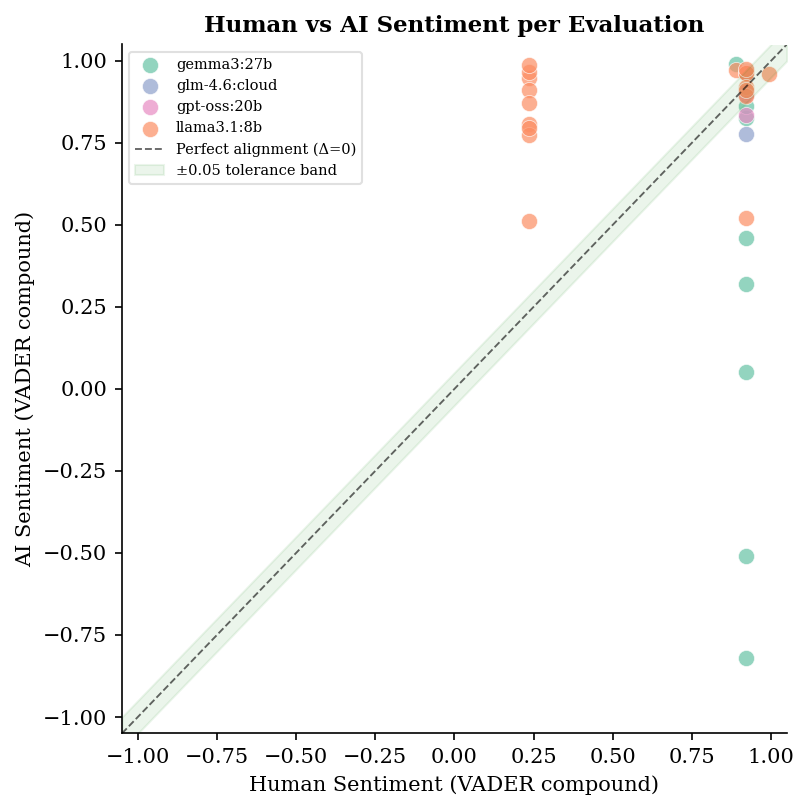

/var/folders/ss/3dfpl8q15vqc9ly63m0zgxp00000gn/T/ipykernel_19238/3872528590.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


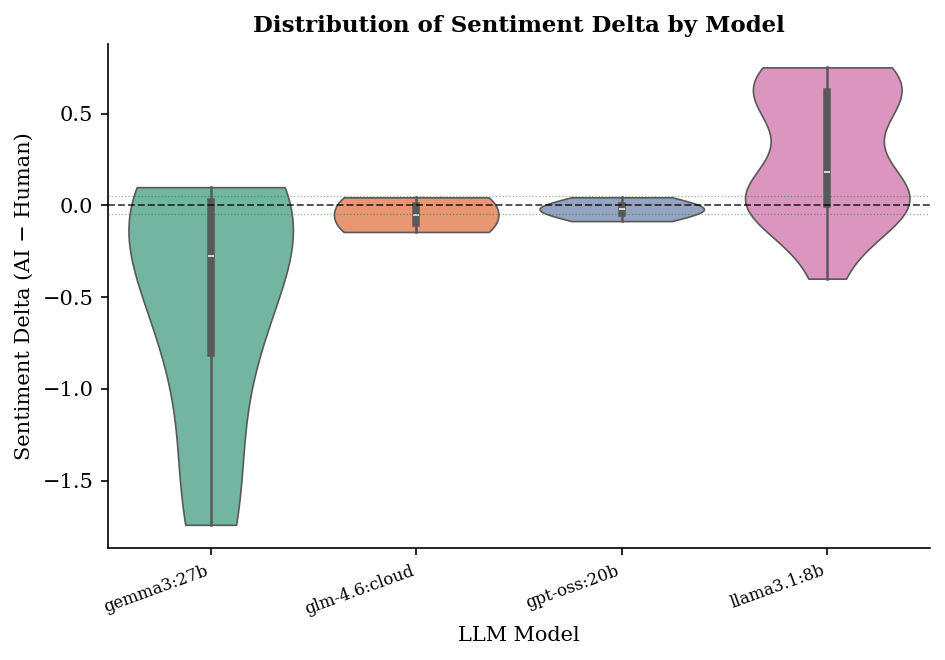

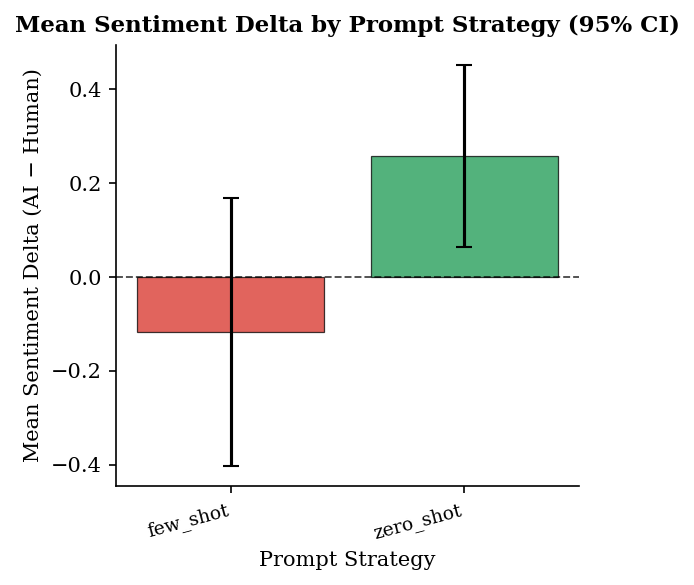

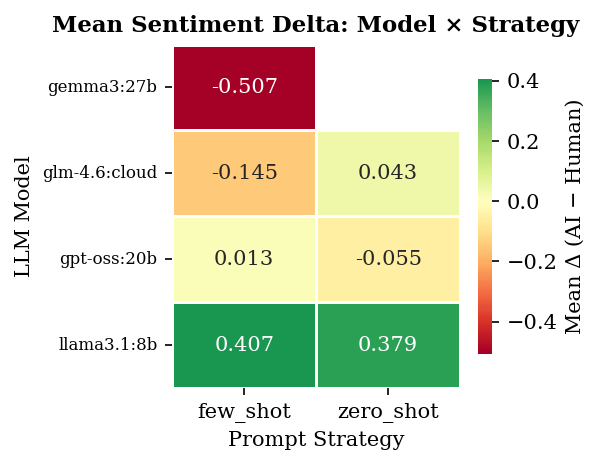


Figures saved to: /Users/eamonn98/Developer/AffectiveTravelogue/backend/figures


In [15]:
# Section 6 — Visualisations

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

matplotlib.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

FIGURES_DIR = os.path.join(os.path.dirname(os.getcwd()), 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- Plot 1: Scatter — human vs AI sentiment with diagonal ---
fig, ax = plt.subplots(figsize=(5.5, 5.5))

scatter_kw = dict(alpha=0.7, edgecolors='white', linewidths=0.4, s=60)
models_unique = df['model_name'].unique()
palette = sns.color_palette('Set2', len(models_unique))
model_colors = dict(zip(models_unique, palette))

for model, grp in df.groupby('model_name'):
    ax.scatter(grp['notes_compound'], grp['generated_compound'],
               color=model_colors[model], label=model, **scatter_kw)

lims = [-1.05, 1.05]
ax.plot(lims, lims, 'k--', linewidth=0.9, alpha=0.6, label='Perfect alignment (Δ=0)')
ax.fill_between(lims, [l - 0.05 for l in lims], [l + 0.05 for l in lims],
                alpha=0.08, color='green', label='±0.05 tolerance band')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Human Sentiment (VADER compound)', fontsize=10)
ax.set_ylabel('AI Sentiment (VADER compound)', fontsize=10)
ax.set_title('Human vs AI Sentiment per Evaluation', fontsize=11, fontweight='bold')
ax.legend(fontsize=7, framealpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'vader_scatter_alignment.pdf'), bbox_inches='tight')
plt.show()

# --- Plot 2: Violin — sentiment delta by model ---
fig, ax = plt.subplots(figsize=(max(5, df['model_name'].nunique() * 1.6), 4.5))

order = df.groupby('model_name')['delta'].mean().sort_values().index.tolist()
sns.violinplot(
    data=df, x='model_name', y='delta', order=order,
    palette='Set2', inner='box', cut=0, linewidth=0.8, ax=ax
)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.7)
ax.axhline(0.05,  color='green', linewidth=0.6, linestyle=':', alpha=0.5)
ax.axhline(-0.05, color='green', linewidth=0.6, linestyle=':', alpha=0.5)
ax.set_xlabel('LLM Model', fontsize=10)
ax.set_ylabel('Sentiment Delta (AI − Human)', fontsize=10)
ax.set_title('Distribution of Sentiment Delta by Model', fontsize=11, fontweight='bold')
plt.xticks(rotation=20, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'vader_violin_delta_model.pdf'), bbox_inches='tight')
plt.show()

# --- Plot 3: Bar chart — mean delta by prompt strategy with 95% CI ---
fig, ax = plt.subplots(figsize=(max(4, df['prompt_strategy'].nunique() * 1.4), 4))

strat_order = df.groupby('prompt_strategy')['delta'].mean().sort_values().index.tolist()
means = df.groupby('prompt_strategy')['delta'].mean().reindex(strat_order)
sems  = df.groupby('prompt_strategy')['delta'].sem().reindex(strat_order)
ci95  = sems * 1.96

colors = ['#d73027' if m < 0 else '#1a9850' for m in means]
bars = ax.bar(strat_order, means, yerr=ci95, capsize=4,
              color=colors, alpha=0.75, edgecolor='black', linewidth=0.6)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.7)
ax.set_xlabel('Prompt Strategy', fontsize=10)
ax.set_ylabel('Mean Sentiment Delta (AI − Human)', fontsize=10)
ax.set_title('Mean Sentiment Delta by Prompt Strategy (95% CI)', fontsize=11, fontweight='bold')
plt.xticks(rotation=15, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'vader_bar_strategy.pdf'), bbox_inches='tight')
plt.show()

# --- Plot 4: Heatmap — mean delta by model × strategy ---
pivot = df.pivot_table(values='delta', index='model_name',
                       columns='prompt_strategy', aggfunc='mean')

if pivot.shape[0] > 1 and pivot.shape[1] > 1:
    fig, ax = plt.subplots(figsize=(max(4, pivot.shape[1] * 1.5), max(3, pivot.shape[0] * 0.8)))
    sns.heatmap(
        pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Mean Δ (AI − Human)', 'shrink': 0.8},
        ax=ax
    )
    ax.set_xlabel('Prompt Strategy', fontsize=10)
    ax.set_ylabel('LLM Model', fontsize=10)
    ax.set_title('Mean Sentiment Delta: Model × Strategy', fontsize=11, fontweight='bold')
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'vader_heatmap_model_strategy.pdf'), bbox_inches='tight')
    plt.show()
else:
    print("Skipping heatmap — insufficient model × strategy combinations in the data.")

print(f"\nFigures saved to: {FIGURES_DIR}")

# Section 7 — Psychogeographic Interpretation

## Affective Faithfulness of AI-Generated Travelogues

The VADER compound score operates on a scale of −1 (maximally negative) to +1 (maximally positive). The sentiment delta Δ = AI − human therefore encodes the direction and magnitude of any affective shift introduced by the generative model relative to the human-authored reference text.

### Interpreting Δ

| Delta range | Psychogeographic classification | Implication |
|-------------|--------------------------------|-------------|
| Δ > +0.05   | **Romanticises** | The AI narrates the walk with more positive affect than the human author; it aestheticises or embellishes the experience |
| −0.05 ≤ Δ ≤ +0.05 | **Affectively faithful** | The AI preserves the emotional register of the walk within a margin consistent with VADER's lexical resolution |
| Δ < −0.05   | **Dampens** | The AI narrates the walk with reduced or more negative affect; emotional nuance present in the human text is suppressed |

### Theoretical implications

Following Debord's (1955) formulation, a travelogue that systematically romanticises places imposes an external affective template over the walker's experience — analogous to the spectacle replacing lived geography with a curated representation. A model that *dampens* affect risks producing a bureaucratic or neutral account that severs the connective tissue between place and feeling that psychogeographic writing is intended to preserve.

An ideal generative system for psychogeographic travelogue production would exhibit Δ ≈ 0 across diverse walks, models, and prompting strategies, demonstrating that the system functions as an affectively neutral amplifier of the walker's own registered experience rather than as an autonomous aesthetic agent.

### Limitations

VADER was developed for social media text and may systematically mis-score literary or descriptive prose. Compound scores aggregated at the full-travelogue level also obscure localised affective variation across individual waypoints — a limitation that waypoint-level analysis (available through the `pair_f1` fields in the BERTScore evaluation) would partially address.

---

**References**

- Debord, G. (1955). Introduction to a Critique of Urban Geography. *Les Lèvres Nues*, 6.
- Hutto, C.J. & Gilbert, E.E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text. *Proceedings of the 8th International AAAI Conference on Weblogs and Social Media (ICWSM-14)*.
- Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). Lawrence Erlbaum Associates.
- Dunn, O.J. (1964). Multiple comparisons using rank sums. *Technometrics*, 6(3), 241–252.